In [72]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from copy import deepcopy

from openquake.hazardlib.imt import PGA, SA, RSD595, AvgSA, IMT

from pickagm.distributions import (
    ensemble_ecdfs, 
    ensemble_quantiles,
    ensemble_ks_test,
    ensemble_r_score,
    ensemble_ks_bounds
    )

from phd_project.config import config
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    ESHM20SiteRupCtxBuilder,
    create_gmm_map,
    create_corr_model_map,
    adjust_ensemble_distributions,
    greedy_optimise_ensemble,
    sse_point_stats,
    weighted_ks_statistic,
    weighted_ks_statistic_and_failing_im_penalty,
    total_ks_statistic,
    total_ks_statistic_and_failing_im_penalty,
    weighted_ks_statistic_and_L2norm_penalty,
    assemble_ensemble_dict
)
import phd_project.scripts.WP1_ground_motion_set.manage_flatfiles as mf
from phd_project.plotting import custom_log_formatter, plot_im_ecdf_vs_target

cfg = config.load_config()

In [74]:
# load the site file
sites = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])

# load the flatfiles
flatfile_folder = cfg["proc_data"]["corr_model"] / "reverse" / "flatfiles"
flatfiles = {}
for f in [f for f in os.listdir(flatfile_folder) if f.endswith(".csv")]:
    tag = f.split("_")[0]
    flatfiles[tag] = pd.read_csv(flatfile_folder / f, delimiter=";", index_col=0, low_memory=False)

flatfiles["volcanic"] = pd.read_csv(cfg["raw_data"]["gm_flatfiles"] / "volcanic_lanzanoluzi_flatfile.csv", 
                                    delimiter=";", index_col=0)

# load the preprocessed gm database
gm_database = pd.read_csv(cfg["proc_data"]["gm_database"], sep=",", low_memory=False, header=[0, 1])

# create the average depth map for each TRT
average_depths = {
    "Craton": flatfiles["asc"]["ev_depth_km"].mean(),
    "Non-Subduction Deep": flatfiles["vran"]["ev_depth_km"].mean(),
    "Shallow Default": flatfiles["asc"]["ev_depth_km"].mean(),
    "Subduction Inslab": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Subduction Interface": flatfiles["sinter"]["ev_depth_km"].mean(),
    "Volcanic": flatfiles["volcanic"]["ev_depth_km"].mean(),
}

# the map of what sim trts are allowed to match with what record trts
OK_TRT_MATCHES = {
    "Craton": ["Shallow Default"],
    "Non-Subduction Deep": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Shallow Default": ["Shallow Default"],
    "Subduction Inslab": ["Non-Subduction Deep", "Subduction Inslab", "Subduction"],
    "Subduction Interface": ["Subduction Interface"],
    "Volcanic": ["Shallow Default"],
}

occurence = True    # the record selection should be performed based on occurence

# AvgSA([0, 6])

In [ ]:
# set some parameters for the selection
t_lower = 0.025     # lower SA period considered in selection
t_upper = 6         # upper SA period considered in selection
n_periods = 20      # number of periods to consider in selection

conditioning_imt: IMT = AvgSA([0,6])                      
nonSA_imts: list[IMT] = [AvgSA([0,6]), RSD595(), PGA()] 
sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
SA_imts: list[IMT] = [SA(period) for period in sa_periods]
selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts    # not AvgSA but the others (PGA and RSD595)
nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# weights of the IMs
weight_rsd595 = 0.25
n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
                        else weight_rsd595 for imt in selection_imts])
imt_weights /= imt_weights.sum()

# some other things
disagg_type = "TRT_Mag_Dist_Eps"
percentiles = [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95]     # percentiles of the gcim distribution to return  
assumed_rake = -90                                # assumed rake for RSD595 calculation

# filter the gm_database so that only the selection and conditioning ims are present
gm_db = gm_database.copy()
updated_ims = mf.filter_gm_database_on_imts(
    gm_db["ims"], selection_imts + [conditioning_imt])
updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
gm_db = pd.concat([gm_db.drop('ims', axis=1, level=0), updated_ims], axis=1)

# Create the GMM Map for AvgSA by reading the logic tree
AvgSA_06_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to6_median_branch.xml"
gmm_map = create_gmm_map(AvgSA_06_lt_fp)

# get the correlation model map
corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

# load disaggregation data
fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_data_60sites.pickle"
with open(fp, "rb") as f:
    disagg_data = pickle.load(f)
    
# organise the disagg data
site_poe_disaggs = {}
for (s, r) in disagg_data.keys():
    for site in disagg_data[(s,r)].keys():
        for poe in disagg_data[(s,r)][site][conditioning_imt.name].keys():
            site_poe_disaggs[(site, poe)] = disagg_data[(s,r)][site][conditioning_imt.name][poe]
site_poes = sorted(list(site_poe_disaggs.keys()), key=lambda x: x[0])

fp = cfg["proc_data"]["site_hazard"] / "AvgSA_06_disagg_stats_60sites.pickle"
with open(fp, "rb") as f:
    disagg_stats= pickle.load(f)

# load the gcim distribution data
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06_rake{int(assumed_rake)}.pickle"
with open(gcim_dist_fp, "rb") as file:
    gcim_dists = pickle.load(file)

# load the preliminary record selection data
preliminary_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_prelim_selection_rake{int(assumed_rake)}.pickle"

with open(preliminary_selection_fp, "rb") as file:
    preliminary_ensembles = pickle.load(file)

preliminary_ensembles = {k: v for k, v in sorted(preliminary_ensembles.items())}

# # load the optimised ensemble data from the original record selection
# optimised_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_optimised_selection_rake{int(assumed_rake)}.pickle"
# with open(optimised_selection_fp, "rb") as file:
#     optimised_ensembles = pickle.load(file)

# optimised_ensembles = {k: v for k, v in sorted(optimised_ensembles.items())}

In [446]:
basic_selection_ctx = {
    "n_ensembles": 20,
    "n_samples": 30,
    "conditioning_imt": conditioning_imt ,
    "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
    "selection_imts": selection_imts ,
    "imt_weights": imt_weights ,
    "sites": sites ,
    "ctx_builder": ESHM20SiteRupCtxBuilder ,
    "ctx_builder_params": ["average_depths", "assumed_rake"] ,
    "average_depths": average_depths ,
    "assumed_rake": assumed_rake ,
    "gmm_map": gmm_map ,
    "corr_map": corr_map ,
    "m_bound_model": "tarbali_and_bradley_2016" ,
    "d_bound_model": "tarbali_and_bradley_2016" ,
    "vs30_bound_model": "tarbali_and_bradley_2016" ,
    "sf_bounds": (0.04, 20),
    "usable_T": t_upper ,
    "max_n_recs": 3 ,
    "p_value": 0.05 ,
    "ok_trt_matches": OK_TRT_MATCHES ,
    "occurence": True ,
}

In [448]:
site = 36
poe = 0.000201

pr_ensemble = preliminary_ensembles[(site, poe)]
disagg_dist = site_poe_disaggs[(site, poe)]
gcim_dist = gcim_dists[(site, poe)]
target_gcim_cdfs = gcim_dist["cdfs"]

cond_iml = disagg_stats[(disagg_stats["site_id"] == site) &
                        (disagg_stats["poe"] == poe)]["imtl"].iloc[0]

site_selection_ctx = deepcopy(basic_selection_ctx)
site_selection_ctx["site_params"] = sites.loc[site,:].to_dict()

print(pr_ensemble["ks_failed_ims"])
new_weight_rsd595 = 0.05
new_weight_sa6pt0 = 0.2
other_weight = (1 - (new_weight_rsd595 + new_weight_sa6pt0)) / (len(selection_imts) - 2)

new_imt_weights = []
for imt in selection_imts:
    if imt.string == "RSD595":
        new_imt_weights.append(new_weight_rsd595)
    elif imt.string == "SA(6.0)":
        new_imt_weights.append(new_weight_rsd595)
    else:
        new_imt_weights.append(other_weight)
        
new_imt_weights = np.array(new_imt_weights)
new_imt_weights /= new_imt_weights.sum()
site_selection_ctx["imt_weights"] = new_imt_weights

['RSD595', 'SA(6.0)']


## Optimise / Adjust Ensemble with different Approaches 

In [449]:
# def create_ensemble(new_recs, target_gcim_cdfs, site_selection_ctx):
#     # do a ks test
#     ks_passed, ks_results, failed_ims = ensemble_ks_test(
#         new_recs["ims_scaled"], target_gcim_cdfs, site_selection_ctx["p_value"])       
#     rscore = ensemble_r_score(ks_results, site_selection_ctx["imt_weights"])
#     ks_bounds = ensemble_ks_bounds(target_gcim_cdfs, site_selection_ctx["n_samples"], site_selection_ctx["p_value"])
#     ecdfs = ensemble_ecdfs(new_recs["ims_scaled"])
#     quantiles = ensemble_quantiles(new_recs["ims_scaled"], qs=[0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.9])
#     mu_lnIM_recs = pd.Series(np.exp(np.mean(np.log(new_recs["ims_scaled"]), axis=0)), index=new_recs["ims_scaled"].columns)
#     sig_lnIM_recs = pd.Series(np.std(np.log(new_recs["ims_scaled"]), axis=0, ddof=1), index=new_recs["ims_scaled"].columns)

#     # create the ensemble dict
#     new_ensemble = {}
#     new_ensemble["recs"] = new_recs
#     new_ensemble["ks_passed"] = ks_passed
#     new_ensemble["ks_results"] = ks_results
#     new_ensemble["ks_failed_ims"] = failed_ims
#     new_ensemble["ks_bounds"] = ks_bounds
#     new_ensemble["R-score"] = rscore
#     new_ensemble["ecdfs"] = ecdfs
#     new_ensemble["quantiles"] = quantiles
#     new_ensemble["mu_lnIM_recs"] = mu_lnIM_recs
#     new_ensemble["sig_lnIM_recs"] = sig_lnIM_recs

#     return new_ensemble

### Ensemble 1: Greedy SSE - $\mu_{lnIM}$ and $\sigma_{lnIM}$

In [ ]:
obj_func = sse_point_stats
obj_func_kwargs = {
    "stat_types": ["mean", "sigma"],
    "target_stats": gcim_dist["stats"][["mean", "sigma"]].to_numpy(),
    "im_weights": site_selection_ctx["imt_weights"],
    "stat_weights": np.array([1, 1])        # equally weighted 
}

# do the optimisation
new_recs, score = greedy_optimise_ensemble(
    pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
    obj_func, obj_func_kwargs)

ensemble_1 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
                                    site_selection_ctx["conditioning_imt"].string,
                                    cond_iml)

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

### Ensemble 2: Greedy SSE - quantiles 0.16, 0.5, 0.84

In [451]:
# obj_func = sse_point_stats
# obj_func_kwargs = {
#     "stat_types": [0.16, 0.5, 0.84],
#     "target_stats": gcim_dist["stats"][["p16", "p50", "p84"]].to_numpy(),
#     "im_weights": site_selection_ctx["imt_weights"],
#     "stat_weights": np.array([1, 1, 1])        # equally weighted 
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_2 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)


### Ensemble 3: Greedy SSE - quantiles 0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95

In [452]:
# obj_func = sse_point_stats
# obj_func_kwargs = {
#     "stat_types": [0.05, 0.16, 0.33, 0.5, 0.67, 0.84, 0.95],
#     "target_stats": gcim_dist["stats"][["p5", "p16", "p33", "p50", "p67", "p84", "p95"]].to_numpy(),
#     "im_weights": site_selection_ctx["imt_weights"],
#     "stat_weights": np.array([1, 1, 1, 1, 1, 1, 1])        # equally weighted 
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_3 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)


### Ensemble 4: Greedy SSE - $\mu_{lnIM}$, $\sigma_{lnIM}$ and quantiles 0.16, 0.5, 0.84

In [453]:
# obj_func = sse_point_stats
# obj_func_kwargs = {
#     "stat_types": ["mean", "sigma", 0.16, 0.5, 0.84],
#     "target_stats": gcim_dist["stats"][["mean", "sigma", "p16", "p50", "p84"]].to_numpy(),
#     "im_weights": site_selection_ctx["imt_weights"],
#     "stat_weights": np.array([1, 2, 1, 1, 1, ])        # give sigma more weight
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_4 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)


### Ensemble 6: Adjustment to reduce the number of failing ims

In [ ]:
# passing, ensemble_out, problem_im = adjust_ensemble_distributions(
#     disagg_dist, target_gcim_cdfs, pr_ensemble, site_selection_ctx, gm_db)

# ensemble_6 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)

KeyboardInterrupt: 

### Ensemble 7: Greedy with weighted KS-statistic

In [455]:
# obj_func = weighted_ks_statistic
# obj_func_kwargs = {
#     "target_cdfs_list": [np.column_stack([np.log(cdf[:,0]), cdf[:,1]]) 
#                             for cdf in target_gcim_cdfs.values()],
#     "im_weights": site_selection_ctx["imt_weights"],
#     "n_recs": site_selection_ctx["n_samples"]
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_7 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)

### Ensemble 8: Greedy with weighted KS-Statistic and Failing IM penalty

In [456]:
# obj_func = weighted_ks_statistic_and_failing_im_penalty
# obj_func_kwargs = {
#     "target_cdfs_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,2]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "upper_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,3]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "lower_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,1]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "im_weights": site_selection_ctx["imt_weights"],
#     "n_recs": site_selection_ctx["n_samples"],
#     "penalty_constant": 10
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_8 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)

### Ensemble 9: Greedy with total KS-Statistic

In [ ]:
# obj_func = total_ks_statistic
# obj_func_kwargs = {
#     "target_cdfs_list": [np.column_stack([np.log(cdf[:,0]), cdf[:,1]]) 
#                             for cdf in target_gcim_cdfs.values()],
#     "n_recs": site_selection_ctx["n_samples"]
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_9 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

### Ensemble 10: Greedy with total KS-Statistic and failing IM penalty

In [ ]:
# obj_func = total_ks_statistic_and_failing_im_penalty
# obj_func_kwargs = {
#     "target_cdfs_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,2]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "upper_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,3]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "lower_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,1]]) 
#                             for ksb in pr_ensemble["ks_bounds"].values()],
#     "n_recs": site_selection_ctx["n_samples"],
#     "penalty_constant": 10
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_10 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
#                                     site_selection_ctx["conditioning_imt"].string,
#                                     cond_iml)

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

### Ensemble 11: Greedy with weighted KS-Statistic + L2 Norm bounds penalty

In [459]:
obj_func = weighted_ks_statistic_and_L2norm_penalty
obj_func_kwargs = {
    "target_cdfs_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,2]]) 
                            for ksb in pr_ensemble["ks_bounds"].values()],
    "upper_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,3]]) 
                            for ksb in pr_ensemble["ks_bounds"].values()],
    "lower_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,1]]) 
                            for ksb in pr_ensemble["ks_bounds"].values()],
    "im_weights": site_selection_ctx["imt_weights"],
    "n_recs": site_selection_ctx["n_samples"],
    "penalty_constant": 100
}

# do the optimisation 
new_recs, score = greedy_optimise_ensemble(
    pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
    obj_func, obj_func_kwargs)

ensemble_11 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
                                    site_selection_ctx["conditioning_imt"].string,
                                    cond_iml)

# do optimisation for 2 different shuffles
new_recs, score = greedy_optimise_ensemble(
    pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
    obj_func, obj_func_kwargs, shuffle=True, rng_seed=1)

ensemble_12 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
                                    site_selection_ctx["conditioning_imt"].string,
                                    cond_iml)

new_recs, score = greedy_optimise_ensemble(
    pr_ensemble, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
    obj_func, obj_func_kwargs, shuffle=True, rng_seed=2)

ensemble_13 = assemble_ensemble_dict(new_recs, target_gcim_cdfs, site_selection_ctx,
                                    site_selection_ctx["conditioning_imt"].string,
                                    cond_iml)

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

## Comparison

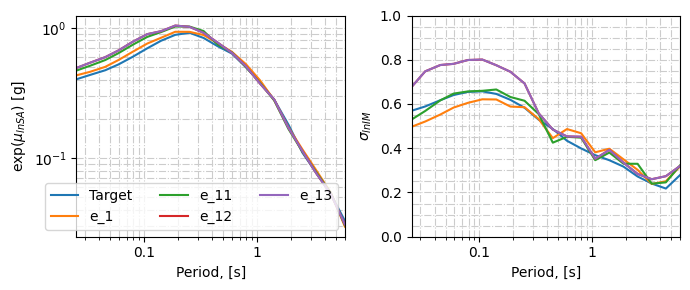

In [474]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

ensembles_to_plot = {
    "e_1": ensemble_1,
    # "e_2": ensemble_2,
    # "e_3": ensemble_3,
    # "e_4": ensemble_4,
    # "e_6": ensemble_6,
    # "e_7": ensemble_7,
    # "e_8": ensemble_8,
    # "e_9": ensemble_9,
    # "e_10": ensemble_10,
    "e_11": ensemble_11,
    "e_12": ensemble_12,
    "e_13": ensemble_13
}

sa_keys = [sa.string for sa in SA_imts]

ax1.loglog(sa_periods, np.exp(gcim_dist["stats"].loc[sa_keys, "mean"]), label="Target")
for k, e in ensembles_to_plot.items():
    ax1.loglog(sa_periods, e["mu_lnIM_recs"][sa_keys], label=k)

ax2.semilogx(sa_periods, gcim_dist["stats"].loc[sa_keys, "sigma"], label="Target")
for k, e in ensembles_to_plot.items():
    ax2.semilogx(sa_periods, e["sig_lnIM_recs"][sa_keys], label=k)

formatter = ticker.FuncFormatter(custom_log_formatter)
ax1.xaxis.set_major_formatter(formatter)
ax1.set_xlim(0.025, 6)
# ax1.set_ylim(1e-2, 0.2)

ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.tick_params(axis='y', which='minor', left=False)
ax1.set_xlabel("Period, [s]")
ax1.set_ylabel(r"exp($\mu_{lnSA}$) [g]")
ax1.legend(ncol=3)

ax2.xaxis.set_major_formatter(formatter)
ax2.set_xlim(0.025, 6)
ax2.set_ylim(0, 1.0)

ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.tick_params(axis='y', which='minor', left=False)
ax2.set_xlabel("Period, [s]")
ax2.set_ylabel(r"$\sigma_{lnIM}$")

fig.tight_layout()

### Rscores

An indication of how close the distributions are to the target distribution

In [475]:
# fig, ax = plt.subplots()
# labels = ensembles_to_plot.keys()
# rscores = [e["R-score"] for e in ensembles_to_plot.values()]

# # Use a colormap to assign different colors to each bar
# colors = plt.cm.tab10(range(1, len(labels)+1))
# ax.set_axisbelow(True)
# ax.grid(True, which="major", axis="y", ls="-.", color="0.8")
# ax.minorticks_on()
# ax.xaxis.set_minor_locator(ticker.NullLocator())
# ax.bar(labels, rscores, color=colors)

# ax.set_ylabel('R-Scores')
# ax.set_xlabel('Optimisation Algorithms / Objectives')

### Heatmaps

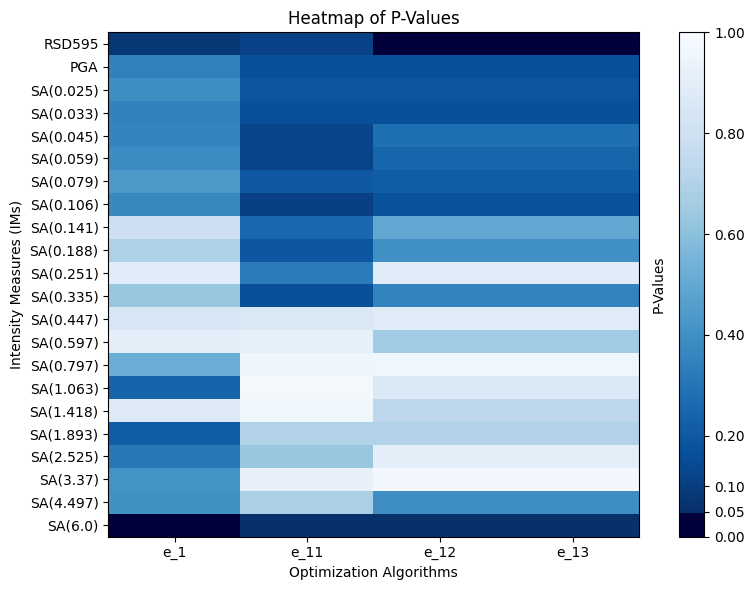

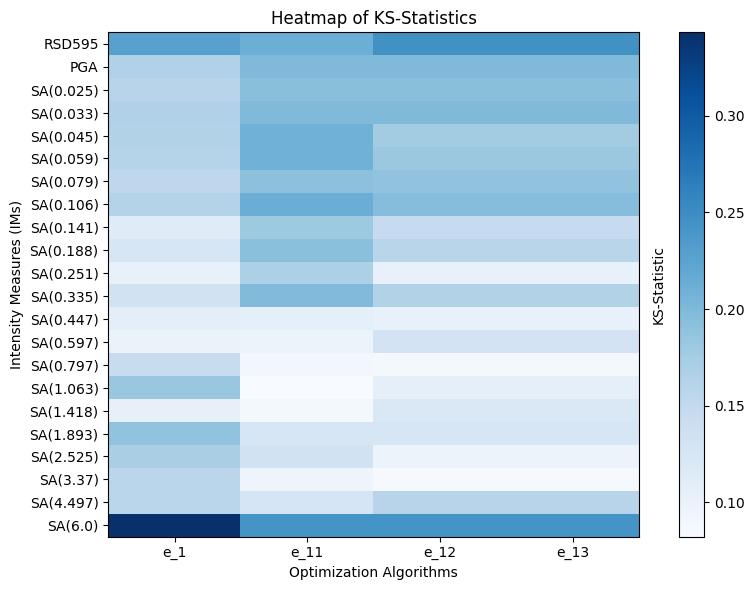

In [476]:
all_pvalues = []
all_ks_stats = []

for k, e in ensembles_to_plot.items():
    ks_result = e["ks_results"]
    pvalues = pd.Series({im:ksr.pvalue for im, ksr in ks_result.items()}, name=k)
    ks_stat =  pd.Series({im:ksr.statistic for im, ksr in ks_result.items()}, name=k)
    
    all_pvalues.append(pvalues)
    all_ks_stats.append(ks_stat)

df_pvalues = pd.concat(all_pvalues, axis=1)
df_ks_stat = pd.concat(all_ks_stats, axis=1)


# Plot heat map of pvalues
fig, ax = plt.subplots(figsize=(8, 6))

# 1. Construct the custom colormap
res = 256
threshold = 0.05
n_scarlet = int(res * threshold)
n_gradient = res - n_scarlet

# Create colour block for failing pvalues and Blue gradient block for passing ones
fail_colour = np.tile(mcolors.to_rgba("#01003A"), (n_scarlet, 1))
gradient = plt.cm.Blues_r(np.linspace(0, 1, n_gradient))
custom_cmap = mcolors.ListedColormap(np.vstack((fail_colour, gradient)))

# 2. Plot heatmap with linear scaling from 0 to 1
im = ax.imshow(df_pvalues.values, cmap=custom_cmap, vmin=0, vmax=1, aspect='auto')

# 3. Configure the color key (colorbar)
# We manually set the ticks as requested
ticks = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
cbar = fig.colorbar(im, ax=ax, ticks=ticks, pad=0.06)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('P-Values', rotation=90, labelpad=10)

# 4. Labeling
ax.set_xticks(np.arange(len(df_pvalues.columns)))
ax.set_xticklabels(df_pvalues.columns, rotation=0, ha="center")
ax.set_yticks(np.arange(len(df_pvalues.index)))
ax.set_yticklabels(df_pvalues.index)

ax.set_xlabel('Optimization Algorithms')
ax.set_ylabel('Intensity Measures (IMs)')
ax.set_title("Heatmap of P-Values")

plt.tight_layout()

# plot heatmap of KS statistics
# Plot heat map of pvalues
fig2, ax2 = plt.subplots(figsize=(8, 6))
# 2. Plot heatmap with linear scaling from 0 to 1
im = ax2.imshow(df_ks_stat.values, cmap=plt.cm.Blues, aspect='auto')

# 3. Configure the color key (colorbar)
# We manually set the ticks as requested
cbar = fig2.colorbar(im, ax=ax2, pad=0.06)
cbar.ax.yaxis.set_label_position('left')
cbar.set_label('KS-Statistic', rotation=90, labelpad=10)

# 4. Labeling
ax2.set_xticks(np.arange(len(df_ks_stat.columns)))
ax2.set_xticklabels(df_ks_stat.columns, rotation=0, ha="center")
ax2.set_yticks(np.arange(len(df_ks_stat.index)))
ax2.set_yticklabels(df_ks_stat.index)

ax2.set_xlabel('Optimization Algorithms')
ax2.set_ylabel('Intensity Measures (IMs)')
ax2.set_title("Heatmap of KS-Statistics")

plt.tight_layout()

### IM Distribution

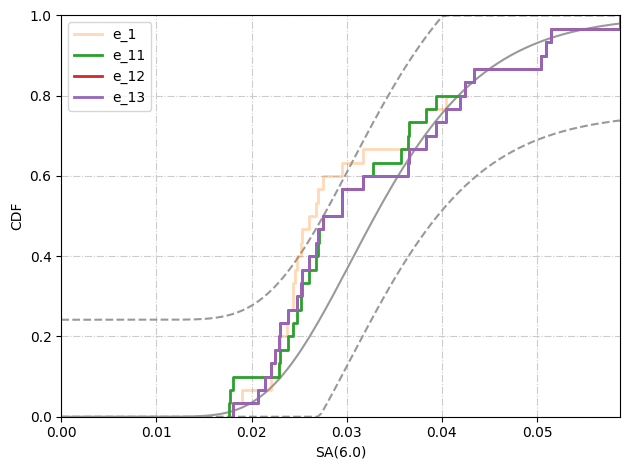

In [477]:
# plot the ecdfs of each ensemble
fig, ax = plt.subplots()
default_cycler = plt.rcParams['axes.prop_cycle']
ax.set_prop_cycle(default_cycler[1:])
im = "SA(6.0)"

alphas = {
    "e_1": 0.3,
    "e_2": 0.3,
    "e_3": 0.3,
    "e_4": 0.3,
    "e_5": 0.3,
    "e_6": 0.3,
    "e_7": 0.3,
    "e_8": 0.3,
    "e_9": 0.3,
    "e_10": 0.3,
    "e_11": 1,
    "e_12": 1,
    "e_13": 1}

# Figure 2 -> RSD595 KS-Test
# target cdf and ks bounds
ks_bounds = ensemble_1["ks_bounds"][im]
xs = ks_bounds[:, 0]
lower = ks_bounds[:, 1]
cdf = ks_bounds[:, 2]
upper = ks_bounds[:, 3]

# the target cdf and bounds
ax.plot(xs, lower, color="0.6", ls="--")
ax.plot(xs, cdf, color="0.6", ls="-")
ax.plot(xs, upper, color="0.6", ls="--")

# the ecdfs
x_max = 0
for k, e in ensembles_to_plot.items():
    ecdf = e["ecdfs"][im] 
    x_max = max(x_max, max(ecdf[:,0]))
    ax.plot(ecdf[:,0], ecdf[:,1], label=k, lw=2, alpha=alphas[k])

ax.set_xlim(0, x_max)
ax.set_ylim(0, 1.0)
ax.set_xlabel(f"{im}")
ax.set_ylabel(r"CDF")
ax.grid(True, which="both", ls="-.", color="0.8")
ax.legend()
fig.tight_layout()


# AvgSA([0, 3])

In [478]:
# # set some parameters for the selection
# t_lower = 0.025     # lower SA period considered in selection
# t_upper = 3         # upper SA period considered in selection
# n_periods = 20      # number of periods to consider in selection

# conditioning_imt: IMT = AvgSA([0,3])                      
# nonSA_imts: list[IMT] = [AvgSA([0,3]), RSD595(), PGA()] 
# sa_periods = np.round(np.geomspace(t_lower, t_upper, num=n_periods), 3)
# SA_imts: list[IMT] = [SA(period) for period in sa_periods]
# selection_imts: list[IMT] = nonSA_imts[1:] + SA_imts
# nonSA_imt_strs: list[str] = [im.string for im in nonSA_imts] # strings match the correlation matrix

# # weights of the IMs
# weight_rsd595 = 0.25
# n_other_ims = len([imt for imt in selection_imts if imt.name == "SA" or imt.name == "PGA"])
# imt_weights = np.array([(1-weight_rsd595) / n_other_ims if imt.name != "RSD595" 
#                         else weight_rsd595 for imt in selection_imts])
# imt_weights /= imt_weights.sum()

# # some other things
# disagg_type = "TRT_Mag_Dist_Eps"
# percentiles = [0.05, 0.16, 0.5, 0.84, 0.95]     # percentiles of the gcim distribution to return  
# assumed_rake = -90                              # assumed rake for RSD595 calculation

# # filter the gm_database so that only the selection and conditioning ims are present
# gm_db = gm_database.copy()
# updated_ims = mf.filter_gm_database_on_imts(
#     gm_db["ims"], selection_imts + [conditioning_imt])
# updated_ims.columns = pd.MultiIndex.from_product([['ims'], updated_ims.columns])
# gm_db = pd.concat([gm_db.drop('ims', axis=1, level=0), updated_ims], axis=1)

# with open(r"C:\Users\clemettn\Documents\gm_db.pickle", "wb") as file:
#     pickle.dump(gm_db, file)
    
# # Create the GMM Map for AvgSA by reading the logic tree
# AvgSA_03_lt_fp = cfg["hazard_models"]["eshm20_AvgSA"] / "gmpe_logic_tree_AvgSA_0to3_median_branch.xml"
# gmm_map = create_gmm_map(AvgSA_03_lt_fp)

# # get the correlation model map
# corr_map = create_corr_model_map(nonSA_imt_strs, sa_periods)

In [479]:
# # set up the selection context:
# basic_selection_ctx = {
#     "n_ensembles": 20,
#     "n_samples": 30,
#     "conditioning_imt": conditioning_imt ,
#     "disagg_imt": conditioning_imt.name , # this only works for AvgSA. otherwise used .string 
#     "selection_imts": selection_imts ,
#     "imt_weights": imt_weights ,
#     "sites": sites ,
#     "ctx_builder": ESHM20SiteRupCtxBuilder ,
#     "ctx_builder_params": ["average_depths", "assumed_rake"] ,
#     "average_depths": average_depths ,
#     "assumed_rake": assumed_rake ,
#     "gmm_map": gmm_map ,
#     "corr_map": corr_map ,
#     "m_bound_model": "tarbali_and_bradley_2016" ,
#     "d_bound_model": "tarbali_and_bradley_2016" ,
#     "vs30_bound_model": "tarbali_and_bradley_2016" ,
#     "sf_bounds": (0.05, 20),
#     "usable_T": t_upper ,
#     "max_n_recs": 3 ,
#     "p_value": 0.05 ,
#     "ok_trt_matches": OK_TRT_MATCHES ,
#     "occurence": True ,
# }

# selection_output_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_03_prelim_selection_rake{int(assumed_rake)}.pickle"
# only_sites = []
# only_poes = []

# if selection_output_fp.is_file():
#     with open(selection_output_fp, "rb") as file:
#         record_selection_results = pickle.load(file)
#     print("Existing record selection data loaded...")
# else:
#     no_file = True
#     print("No existing record selection data found...")

# # load disaggregation data
# fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_data_60sites.pickle"
# with open(fp, "rb") as f:
#     disagg_data = pickle.load(f)

# # organise the disagg data
# site_poe_disaggs = {}
# for (s, r) in disagg_data.keys():
#     for site in disagg_data[(s,r)].keys():
#         for poe in disagg_data[(s,r)][site][conditioning_imt.name].keys():
#             site_poe_disaggs[(site, poe)] = disagg_data[(s,r)][site][conditioning_imt.name][poe]
# site_poes = sorted(list(site_poe_disaggs.keys()), key=lambda x: x[0])

# # load the disaggregation stats
# fp = cfg["proc_data"]["site_hazard"] / "AvgSA_03_disagg_stats_60sites.pickle"
# with open(fp, "rb") as f:
#     disagg_stats= pickle.load(f)

# # load the gcim distribution data
# gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_03_rake{int(assumed_rake)}.pickle"
# with open(gcim_dist_fp, "rb") as file:
#     gcim_dists = pickle.load(file)

In [480]:
# sr = ("high", 0)
# site = 31
# poe = 0.0001

# pr_ensemble = record_selection_results[(site, poe)]
# disagg_dist = site_poe_disaggs[(site, poe)]
# gcim_dist = gcim_dists[(site, poe)]
# target_gcim_cdfs = gcim_dist["cdfs"]

# cond_iml = disagg_stats[(disagg_stats["site_id"] == site) &
#                         (disagg_stats["poe"] == poe)]["imtl"].iloc[0]

# site_selection_ctx = deepcopy(basic_selection_ctx)
# site_selection_ctx["site_params"] = basic_selection_ctx["sites"].loc[site,:].to_dict()
# _ = site_selection_ctx.pop("sites")

# ensemble_og = create_ensemble(pr_ensemble["recs"], target_gcim_cdfs, site_selection_ctx)

## Optimisation - total KS + failing IM penalty

In [481]:
# obj_func = total_ks_statistic_and_failing_im_penalty

# ks_bounds = ensemble_ks_bounds(target_gcim_cdfs, site_selection_ctx["n_samples"], site_selection_ctx["p_value"])

# obj_func_kwargs = {
#     "target_cdfs_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,2]]) 
#                             for ksb in ks_bounds.values()],
#     "upper_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,3]]) 
#                             for ksb in ks_bounds.values()],
#     "lower_ks_bounds_list": [np.column_stack([np.log(ksb[1:,0]), ksb[1:,1]]) 
#                             for ksb in ks_bounds.values()],
#     "n_recs": site_selection_ctx["n_samples"],
#     "penalty_constant": 10
# }

# # do the optimisation
# new_recs, score = greedy_optimise_ensemble(
#     ensemble_og, cond_iml, disagg_dist, gm_db, site_selection_ctx, 
#     obj_func, obj_func_kwargs)

# ensemble_opt = create_ensemble(new_recs, target_gcim_cdfs, site_selection_ctx)

## Comparison

In [482]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

# ensembles_to_plot = {
#     "Orig.": ensemble_og,
#     "Opt.": ensemble_opt,
# }

# sa_keys = [sa.string for sa in SA_imts]

# ax1.loglog(sa_periods, np.exp(gcim_dist["stats"].loc[sa_keys, "mean"]), label="Target")
# for k, e in ensembles_to_plot.items():
#     ax1.loglog(sa_periods, e["mu_lnIM_recs"][sa_keys], label=k)

# ax2.semilogx(sa_periods, gcim_dist["stats"].loc[sa_keys, "sigma"], label="Target")
# for k, e in ensembles_to_plot.items():
#     ax2.semilogx(sa_periods, e["sig_lnIM_recs"][sa_keys], label=k)

# formatter = ticker.FuncFormatter(custom_log_formatter)
# ax1.xaxis.set_major_formatter(formatter)
# ax1.set_xlim(0.025, 3)
# # ax1.set_ylim(1e-2, 0.2)

# ax1.grid(True, which="both", ls="-.", color="0.8")
# ax1.minorticks_on()
# ax1.tick_params(axis='y', which='minor', left=False)
# ax1.set_xlabel("Period, [s]")
# ax1.set_ylabel(r"exp($\mu_{lnSA}$) [g]")
# ax1.legend(ncol=3)

# ax2.xaxis.set_major_formatter(formatter)
# ax2.set_xlim(0.025, 3)
# ax2.set_ylim(0, 1.0)

# ax2.grid(True, which="both", ls="-.", color="0.8")
# ax2.minorticks_on()
# ax2.tick_params(axis='y', which='minor', left=False)
# ax2.set_xlabel("Period, [s]")
# ax2.set_ylabel(r"$\sigma_{lnIM}$")

# fig.tight_layout()

### Rscores

An indication of how close the distributions are to the target distribution

In [483]:
# fig, ax = plt.subplots()
# labels = ensembles_to_plot.keys()
# rscores = [e["R-score"] for e in ensembles_to_plot.values()]

# # Use a colormap to assign different colors to each bar
# colors = plt.cm.tab10(range(1, len(labels)+1))
# ax.set_axisbelow(True)
# ax.grid(True, which="major", axis="y", ls="-.", color="0.8")
# ax.minorticks_on()
# ax.xaxis.set_minor_locator(ticker.NullLocator())
# ax.bar(labels, rscores, color=colors)

# ax.set_ylabel('R-Scores')
# ax.set_xlabel('Optimisation Algorithms / Objectives')

### Heatmaps

In [484]:
# all_pvalues = []
# all_ks_stats = []

# for k, e in ensembles_to_plot.items():
#     ks_result = e["ks_results"]
#     pvalues = pd.Series({im:ksr.pvalue for im, ksr in ks_result.items()}, name=k)
#     ks_stat =  pd.Series({im:ksr.statistic for im, ksr in ks_result.items()}, name=k)
    
#     all_pvalues.append(pvalues)
#     all_ks_stats.append(ks_stat)

# df_pvalues = pd.concat(all_pvalues, axis=1)
# df_ks_stat = pd.concat(all_ks_stats, axis=1)


# # Plot heat map of pvalues
# fig, ax = plt.subplots(figsize=(8, 6))

# # 1. Construct the custom colormap
# res = 256
# threshold = 0.05
# n_scarlet = int(res * threshold)
# n_gradient = res - n_scarlet

# # Create colour block for failing pvalues and Blue gradient block for passing ones
# fail_colour = np.tile(mcolors.to_rgba("#01003A"), (n_scarlet, 1))
# gradient = plt.cm.Blues_r(np.linspace(0, 1, n_gradient))
# custom_cmap = mcolors.ListedColormap(np.vstack((fail_colour, gradient)))

# # 2. Plot heatmap with linear scaling from 0 to 1
# im = ax.imshow(df_pvalues.values, cmap=custom_cmap, vmin=0, vmax=1, aspect='auto')

# # 3. Configure the color key (colorbar)
# # We manually set the ticks as requested
# ticks = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
# cbar = fig.colorbar(im, ax=ax, ticks=ticks, pad=0.06)
# cbar.ax.yaxis.set_label_position('left')
# cbar.set_label('P-Values', rotation=90, labelpad=10)

# # 4. Labeling
# ax.set_xticks(np.arange(len(df_pvalues.columns)))
# ax.set_xticklabels(df_pvalues.columns, rotation=0, ha="center")
# ax.set_yticks(np.arange(len(df_pvalues.index)))
# ax.set_yticklabels(df_pvalues.index)

# ax.set_xlabel('Optimization Algorithms')
# ax.set_ylabel('Intensity Measures (IMs)')
# ax.set_title("Heatmap of P-Values")

# plt.tight_layout()

# # plot heatmap of KS statistics
# # Plot heat map of pvalues
# fig2, ax2 = plt.subplots(figsize=(8, 6))
# # 2. Plot heatmap with linear scaling from 0 to 1
# im = ax2.imshow(df_ks_stat.values, cmap=plt.cm.Blues, aspect='auto')

# # 3. Configure the color key (colorbar)
# # We manually set the ticks as requested
# cbar = fig2.colorbar(im, ax=ax2, pad=0.06)
# cbar.ax.yaxis.set_label_position('left')
# cbar.set_label('KS-Statistic', rotation=90, labelpad=10)

# # 4. Labeling
# ax2.set_xticks(np.arange(len(df_ks_stat.columns)))
# ax2.set_xticklabels(df_ks_stat.columns, rotation=0, ha="center")
# ax2.set_yticks(np.arange(len(df_ks_stat.index)))
# ax2.set_yticklabels(df_ks_stat.index)

# ax2.set_xlabel('Optimization Algorithms')
# ax2.set_ylabel('Intensity Measures (IMs)')
# ax2.set_title("Heatmap of KS-Statistics")

# plt.tight_layout()

### IM Distribution

In [485]:
# # plot the ecdfs of each ensemble
# fig, ax = plt.subplots()
# default_cycler = plt.rcParams['axes.prop_cycle']
# ax.set_prop_cycle(default_cycler[1:])
# im = "SA(3.0)"

# # alphas = {
# #     "e_1": 0.3,
# #     "e_2": 0.3,
# #     "e_3": 0.3,
# #     "e_4": 0.3,
# #     "e_5": 0.3,
# #     "e_6": 1,
# #     "e_7": 1,
# #     "e_8": 1,
# #     "e_9": 1,
# #     "e_10": 1}

# # Figure 2 -> RSD595 KS-Test
# # target cdf and ks bounds
# im_ks_bounds = ks_bounds[im]
# xs = im_ks_bounds[:, 0]
# lower = im_ks_bounds[:, 1]
# cdf = im_ks_bounds[:, 2]
# upper = im_ks_bounds[:, 3]

# # the target cdf and bounds
# ax.plot(xs, lower, color="0.6", ls="--")
# ax.plot(xs, cdf, color="0.6", ls="-")
# ax.plot(xs, upper, color="0.6", ls="--")

# # the ecdfs
# x_max = 0
# for k, e in ensembles_to_plot.items():
#     ecdf = e["ecdfs"][im] 
#     x_max = max(x_max, max(ecdf[:,0]))
#     ax.plot(ecdf[:,0], ecdf[:,1], label=k, lw=2)

# ax.set_xlim(0, x_max)
# ax.set_ylim(0, 1.0)
# ax.set_xlabel(f"{im}")
# ax.set_ylabel(r"CDF")
# ax.grid(True, which="both", ls="-.", color="0.8")
# ax.legend()
# fig.tight_layout()
